In [12]:
# Run garbage collection
import gc
gc.collect()

6539

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler

In [14]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [15]:
path_load = 'data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [14]:
print(X_train[0:1].shape)

(1, 1000, 12)


In [30]:
import numpy as np

class NonLocalCBAMBlock1D_numpy:
    def __init__(self, in_channels=12, reduction=16):
        self.in_channels = in_channels
        self.reduction = reduction

    def conv1d(self, x, kernel_size=3, padding=1):
        # x: (B, C, T)
        B, C, T = x.shape
        pad_x = np.pad(x, ((0,0),(0,0),(padding,padding)), mode='constant')
        out = np.zeros_like(x)
        for b in range(B):
            for c in range(C):
                for t in range(T):
                    out[b, c, t] = np.mean(pad_x[b, c, t:t+kernel_size])
        return out

    def channel_attention(self, x):
        # x: (B, C, T)
        avg_pool = np.mean(x, axis=2, keepdims=True)  # (B, C, 1)
        max_pool = np.max(x, axis=2, keepdims=True)   # (B, C, 1)
        fc1 = np.maximum(0, avg_pool)  # ReLU
        fc2 = np.maximum(0, max_pool)  # ReLU
        attn = 1 / (1 + np.exp(-(fc1 + fc2)))  # Sigmoid
        return attn

    def temporal_attention(self, x):
        # x: (B, C, T)
        avg_out = np.mean(x, axis=1, keepdims=True)  # (B, 1, T)
        max_out = np.max(x, axis=1, keepdims=True)   # (B, 1, T)
        x_cat = np.concatenate([avg_out, max_out], axis=1)  # (B, 2, T)
        attn = 1 / (1 + np.exp(-x_cat.sum(axis=1, keepdims=True)))  # (B, 1, T)
        return attn

    def non_local(self, x):
        # x: (B, C, T)
        B, C, T = x.shape
        inter_C = C // 2
        theta = x[:, :inter_C, :]  # (B, C//2, T)
        phi = x[:, :inter_C, :]    # (B, C//2, T)
        g = x[:, :inter_C, :]      # (B, C//2, T)
        theta = np.transpose(theta, (0, 2, 1))  # (B, T, C//2)
        phi = phi  # (B, C//2, T)
        g = np.transpose(g, (0, 2, 1))  # (B, T, C//2)
        attention = np.matmul(theta, phi)  # (B, T, T)
        attention = np.exp(attention) / np.sum(np.exp(attention), axis=-1, keepdims=True)  # softmax
        out = np.matmul(attention, g)  # (B, T, C//2)
        out = np.transpose(out, (0, 2, 1))  # (B, C//2, T)
        # Project back to original channels (simple pad)
        out_padded = np.pad(out, ((0,0),(0,C-inter_C),(0,0)), mode='constant')
        return out_padded + x  # residual

    def forward(self, x):
        # x: (B, T, C)
        x = np.transpose(x, (0, 2, 1))  # (B, C, T)
        out = self.conv1d(x)
        out = out * self.channel_attention(out)
        out = out * self.temporal_attention(out)
        out = self.non_local(out)
        return np.transpose(out, (0, 2, 1))  # (B, T, C)

In [31]:
object = NonLocalCBAMBlock1D_numpy(in_channels=12, reduction=16)
ncbam = object.forward(X_train[0:1, :, :])

In [32]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    ecg_leads = {
        0: "I",
        1: "II",
        2: "III",
        3: "aVR",
        4: "aVL",
        5: "aVF",
        6: "V1",
        7: "V2",
        8: "V3",
        9: "V4",
        10: "V5",
        11: "V6"
    }
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {ecg_leads[i]}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

Class [1. 0. 0. 0. 0.]


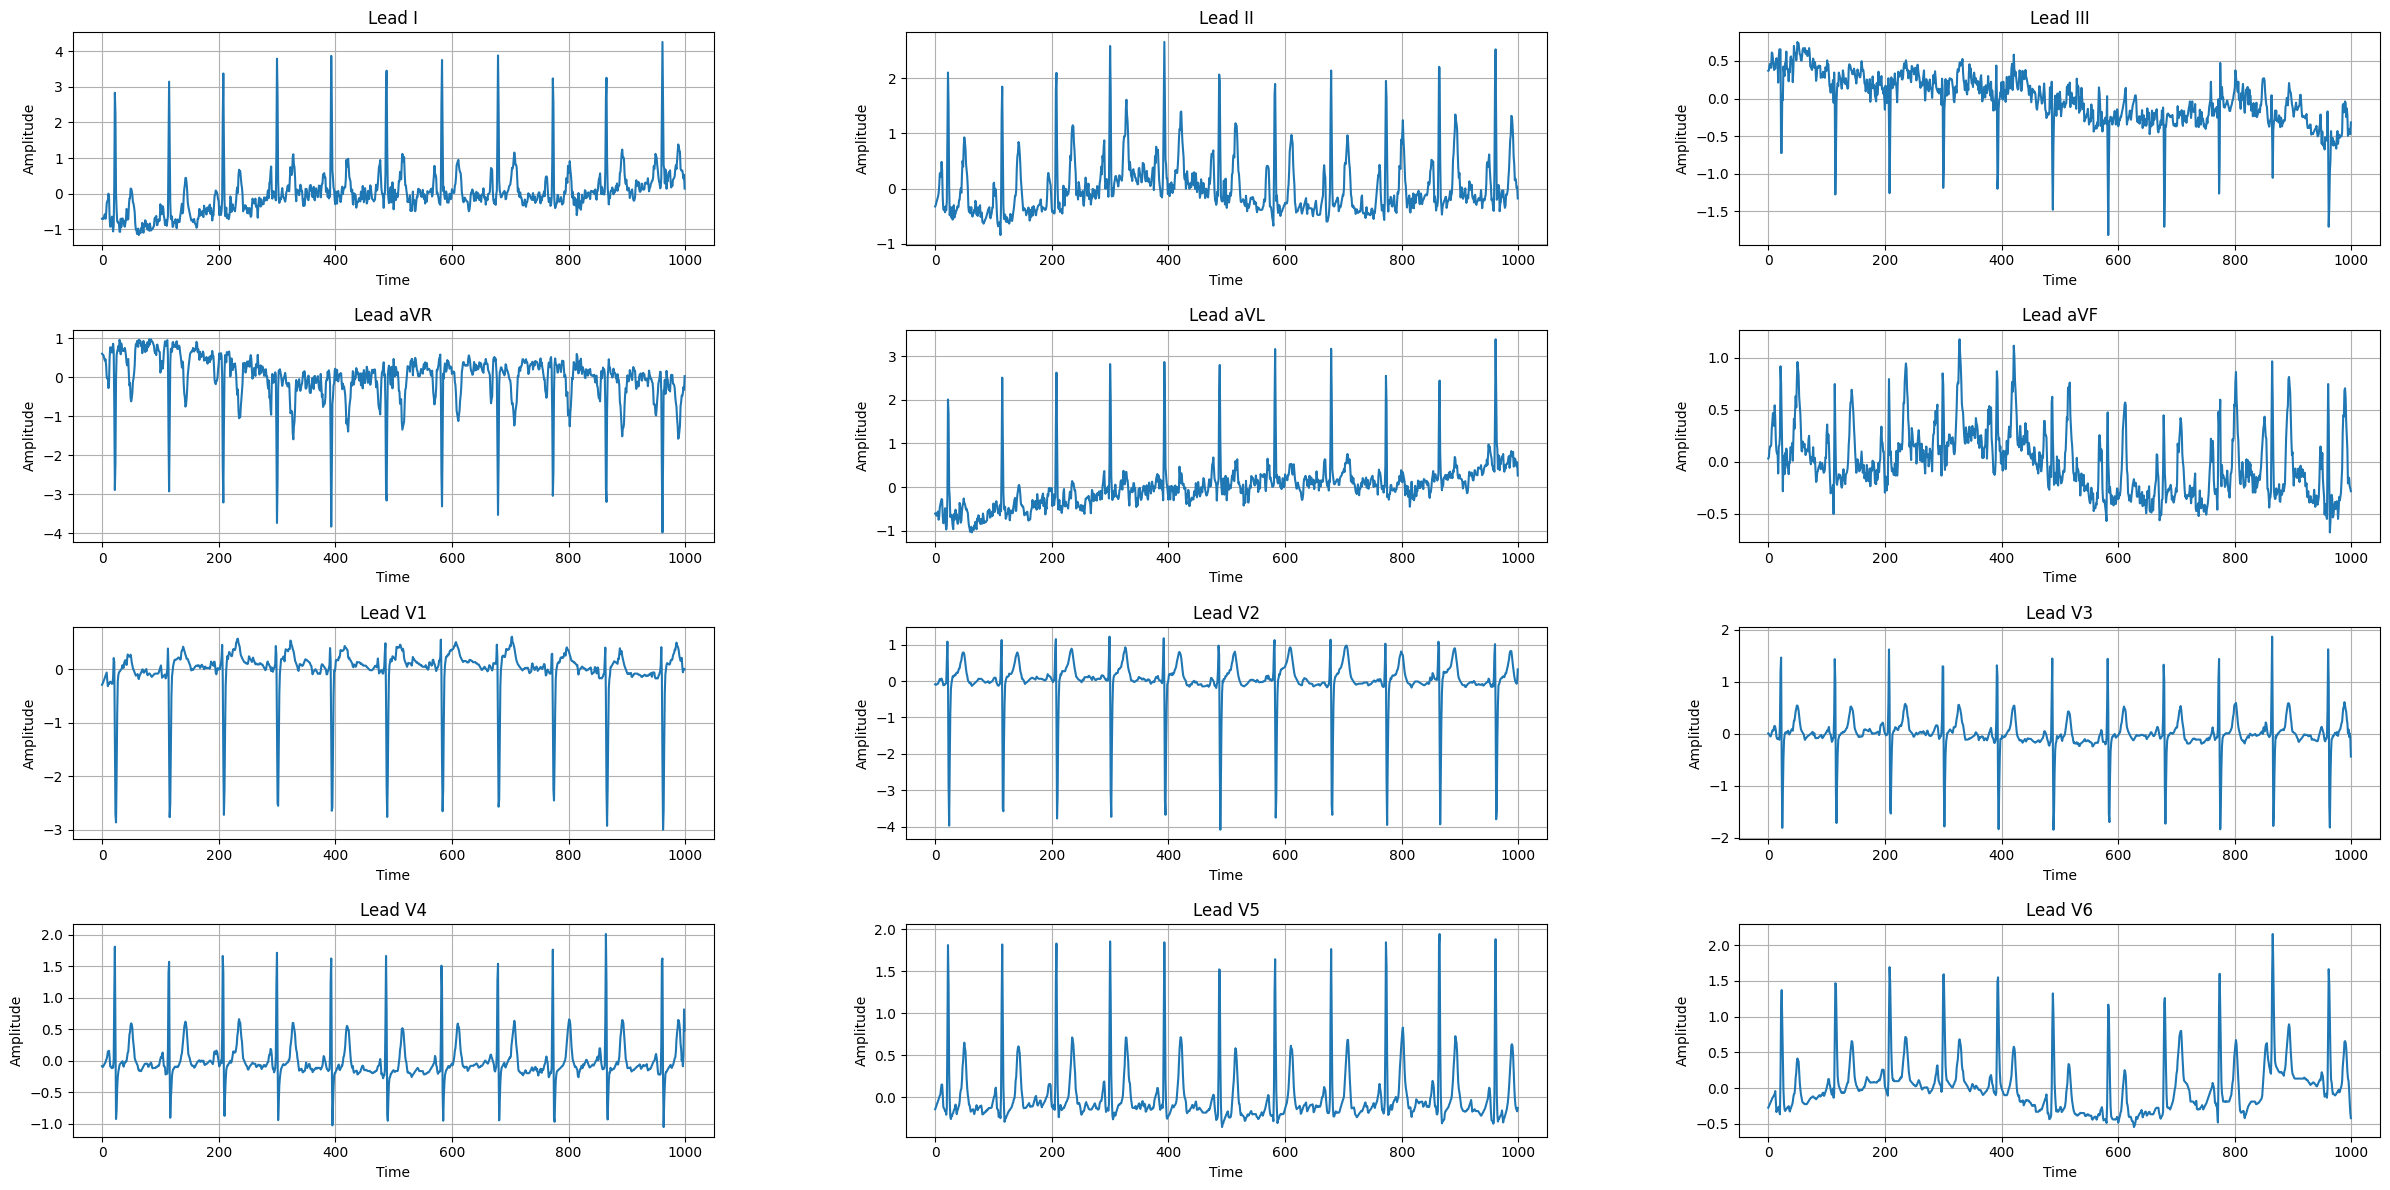

In [35]:
plot_ecg_12_leads(X_train[0,:,:], y_train[1])

In [37]:
def fft_transform(data):
    
    # Apply FFT along the time axis (axis=1), keep only positive frequencies
    fft_data = np.fft.fft(data, axis=1)[:, :data.shape[1] // 2, :]

    # Get positive frequency bins
    frequencies = np.fft.fftfreq(data.shape[1], d=1/1000)[:data.shape[1] // 2]

    # Magnitude of FFT
    magnitude = np.abs(fft_data)
    return frequencies, magnitude    

In [38]:
frequencies, magnitude = fft_transform(X_train[0:1, :, :])

Class ['NORM']


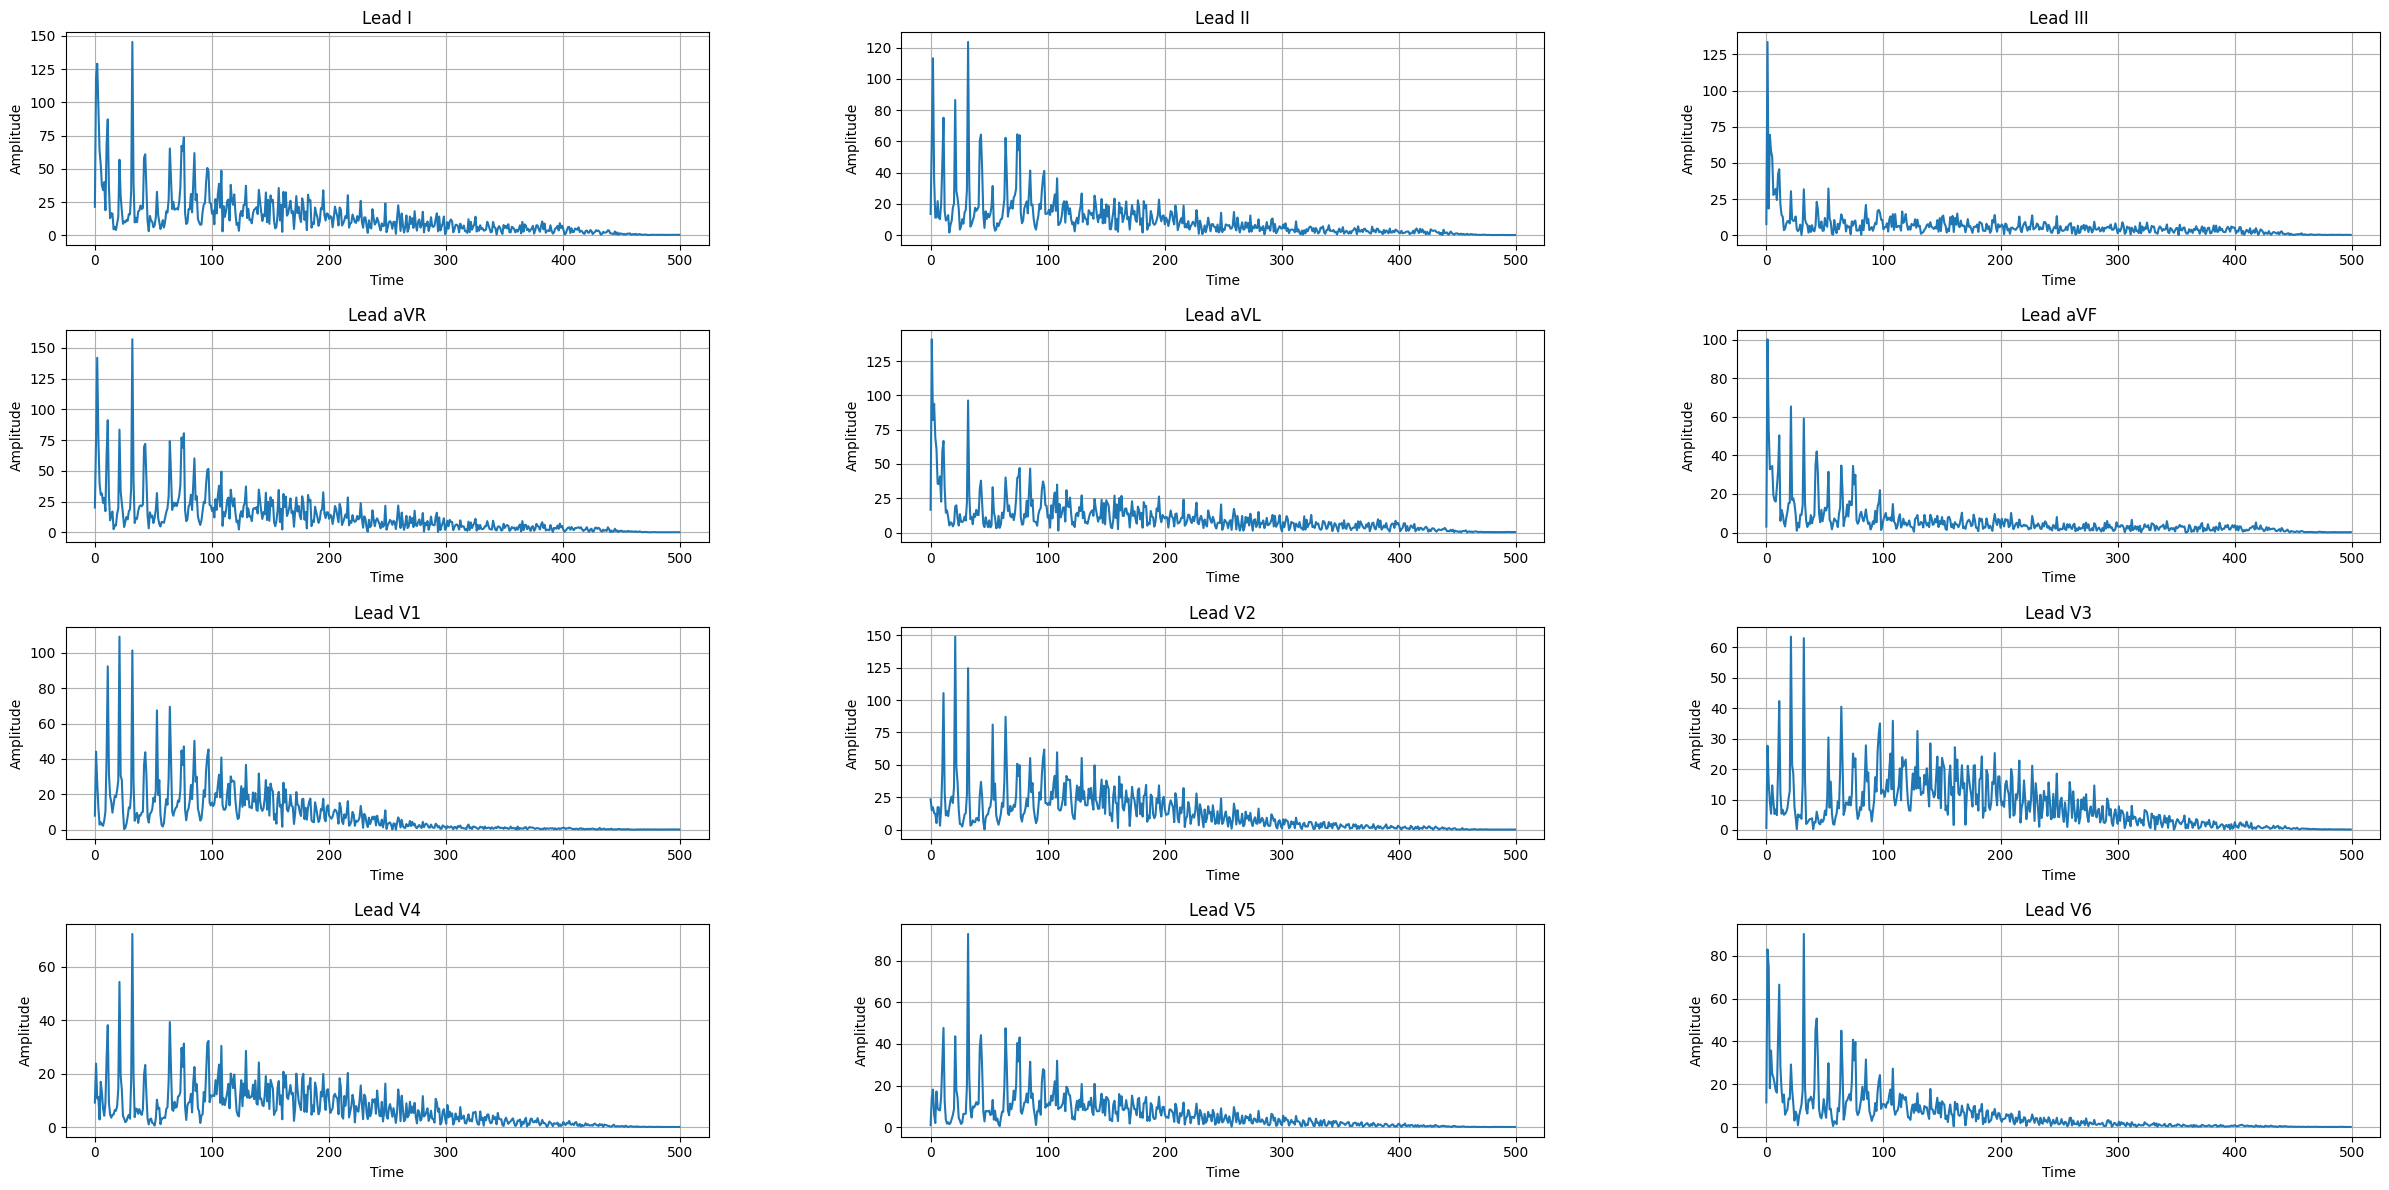

In [43]:
plot_ecg_12_leads(magnitude.squeeze())

In [16]:
print(X_train[0:1, :, :].shape)

(1, 1000, 12)


In [59]:
import torch
import pywt

# Example ECG data with shape (B, 1000, 12)
B, T, F = 4, 1000, 12
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Simulate input data (replace this with X_train or your data)
data = torch.randn(B, T, F, device=device)  # Example ECG data

# Time-domain feature extraction for each lead (column)
def extract_time_domain_features(ecg_signal):
    features = []
    features.append(ecg_signal.mean())  # Mean
    features.append(ecg_signal.std())   # Standard deviation
    features.append(ecg_signal.max() - ecg_signal.min())  # Peak-to-peak amplitude
    features.append(torch.sqrt(torch.mean(ecg_signal**2)))  # RMS

    # Skewness and Kurtosis calculation using PyTorch
    n = ecg_signal.size(0)
    mean = features[0]  # mean
    std = features[1]   # std

    # Skewness
    skewness = torch.sum(((ecg_signal - mean) / std)**3) / n

    # Kurtosis
    kurtosis = torch.sum(((ecg_signal - mean) / std)**4) / n - 3

    features.append(skewness)
    features.append(kurtosis)

    return features

# Frequency-domain feature extraction using FFT (PyTorch)
def extract_frequency_domain_features(ecg_signal, sampling_rate=1):
    features = []

    # Perform FFT and calculate Power Spectral Density (PSD)
    fft_vals = torch.fft.fft(ecg_signal)
    psd = torch.abs(fft_vals)**2 / T  # Normalizing the power spectrum

    # Frequency axis (in Hz)
    freqs = torch.fft.fftfreq(T, d=1/sampling_rate).to(device)

    # Dominant frequency is the one with the highest power
    dominant_freq = freqs[torch.argmax(psd)]
    features.append(dominant_freq)

    # Spectral Entropy (calculation)
    psd_normalized = psd / torch.sum(psd)
    spectral_entropy = -torch.sum(psd_normalized * torch.log(psd_normalized + 1e-10))  # Avoid log(0)
    features.append(spectral_entropy)

    return features

# Continuous Wavelet Transform (CWT) features (coefficients)
def extract_wavelet_features(ecg_signal, scales=torch.arange(1, 128), wavelet_name='cmor1.0-0.5', device='cuda'):
    # Perform the Continuous Wavelet Transform
    coef, _ = pywt.cwt(ecg_signal.cpu().numpy(), scales.cpu().numpy(), wavelet_name)

    # Convert to a PyTorch tensor
    coef_tensor = torch.tensor(coef, device=device)

    # Example: Take the mean of wavelet coefficients across scales
    return coef_tensor.mean(dim=1)

# Main extraction loop to process batch (B, 1000, 12) into (B, num_features, 12)
def extract_features(data):
    B, T, F = data.shape
    all_features = []

    for b in range(B):
        features_batch = []
        for f in range(F):  # For each lead (12 leads)
            ecg_signal = data[b, :, f]  # Shape (1000,)

            # Extract time-domain features
            time_features = extract_time_domain_features(ecg_signal)

            # Extract frequency-domain features
            freq_features = extract_frequency_domain_features(ecg_signal)

            # Extract wavelet features
            wavelet_features = extract_wavelet_features(ecg_signal)

            # Combine all features into a single list
            features = time_features + freq_features + list(wavelet_features)

            # Convert the list of features to a tensor
            features_tensor = torch.tensor(features, device=device)

            features_batch.append(features_tensor)

        # Stack features for all leads into a batch tensor (shape: [num_features, 12])
        all_features.append(torch.stack(features_batch, dim=0))  # Stack across leads

    # Convert to a tensor of shape (B, num_features, 12)
    return torch.stack(all_features, dim=0)  # Stack across batches

# Extract features for the entire batch
all_features_tensor = extract_features(data)

# Check the resulting tensor's shape
print(all_features_tensor.shape)  # Expected shape: (B, num_features, 12)
print(all_features_tensor[0])  # Print features for the first batch

torch.Size([4, 12, 135])
tensor([[ 7.9538e-03+0.0000j,  9.9607e-01+0.0000j,  6.2558e+00+0.0000j,
          ...,  2.6789e-02-0.0423j,  2.6168e-02-0.0418j,
          2.5772e-02-0.0421j],
        [ 3.5883e-03+0.0000j,  9.8571e-01+0.0000j,  7.4360e+00+0.0000j,
          ...,  5.6754e-03-0.0043j,  6.3677e-03-0.0037j,
          6.0611e-03-0.0033j],
        [ 2.3596e-02+0.0000j,  1.0072e+00+0.0000j,  7.2550e+00+0.0000j,
          ...,  2.0988e-02-0.0483j,  2.1042e-02-0.0491j,
          2.1492e-02-0.0493j],
        ...,
        [ 2.8186e-02+0.0000j,  1.0297e+00+0.0000j,  6.6874e+00+0.0000j,
          ...,  3.2901e-03-0.0091j,  3.4198e-03-0.0097j,
          3.6816e-03-0.0099j],
        [ 1.5976e-02+0.0000j,  1.0274e+00+0.0000j,  5.8842e+00+0.0000j,
          ...,  2.7482e-02+0.0071j,  2.8359e-02+0.0072j,
          2.8307e-02+0.0081j],
        [-3.2896e-02+0.0000j,  1.0035e+00+0.0000j,  6.8586e+00+0.0000j,
          ..., -4.2083e-02+0.0034j, -4.2237e-02+0.0040j,
         -4.2457e-02+0.0042j]], d